## Republican County Demographic Analysis

* The purpose of this notebook is to conduct some of the initial analysis on the Republican voting counties in California. Ultimately, this analysis intends to help our group understand the profiles of the counties that go red. What is their racial make up? What kind of industries of employment are prevalent? What are the median age and income?
* The steps to this analysis are: 1) use the cleaned county election data to determine which counties in California voted Republican. 2) Create bar charts to determine racical and industry of employment breakdown in each county. 3) Pull out median age and household income in the county.

### Setup

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

* Loading in data

In [2]:
election = pd.read_csv('../data/clean_data/california_county_voting_cleaned.csv')

ACS_final = pd.read_csv('../data/clean_data/ACS_final.csv')

In [3]:
election.shape

(406, 7)

* Subsetting for counties where Republicans won in 2024

In [4]:
election[(election['rep_share'] > 0.5) & (election['year'] == 2024)]

,county_name,county_fips,year,dem_share,rep_share,margin,winner
2,Amador,6005,2024,0.347409,0.625720,0.278311,Republican
4,Calaveras,6009,2024,0.346715,0.627832,0.281118,Republican
5,Colusa,6011,2024,0.346247,0.628685,0.282438,Republican
7,Del Norte,6015,2024,0.403824,0.567872,0.164048,Republican
8,El Dorado,6017,2024,0.426338,0.546152,0.119814,Republican
9,Fresno,6019,2024,0.465125,0.508979,0.043854,Republican
10,Glenn,6021,2024,0.312201,0.661176,0.348975,Republican
14,Kern,6029,2024,0.382145,0.592697,0.210552,Republican
15,Kings,6031,2024,0.373943,0.604178,0.230235,Republican
17,Lassen,6035,2024,0.217923,0.757981,0.540058,Republican


* Let's explore the demographics of two counties: Tulare and Modoc
* Subetting Tulare County, selecting race percentage columns, and building bar chart for race

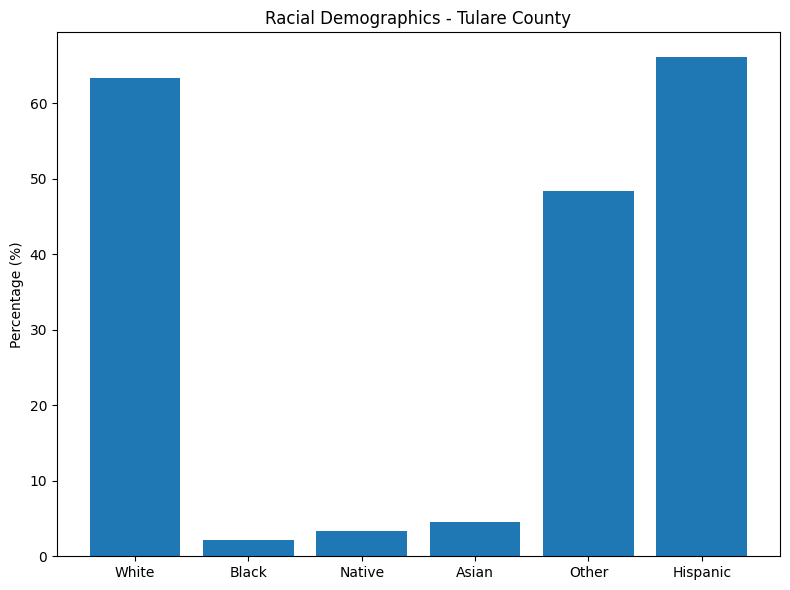

In [5]:
tulare = ACS_final[ACS_final['county'] == 'Tulare County'].iloc[0]

race_labels = ['White', 'Black', 'Native', 'Asian', 'Other', 'Hispanic']
race_cols   = ['pct_white', 'pct_black', 'pct_native', 'pct_asian', 'pct_other', 'pct_hispanic']
race_values = tulare[race_cols].values

plt.figure(figsize=(8, 6))
plt.bar(race_labels, race_values)
plt.ylabel('Percentage (%)')
plt.title('Racial Demographics - Tulare County')
plt.tight_layout()
plt.show()

* Subetting Tulare County, selecting industry percentage columns, and building bar chart for industry of employment

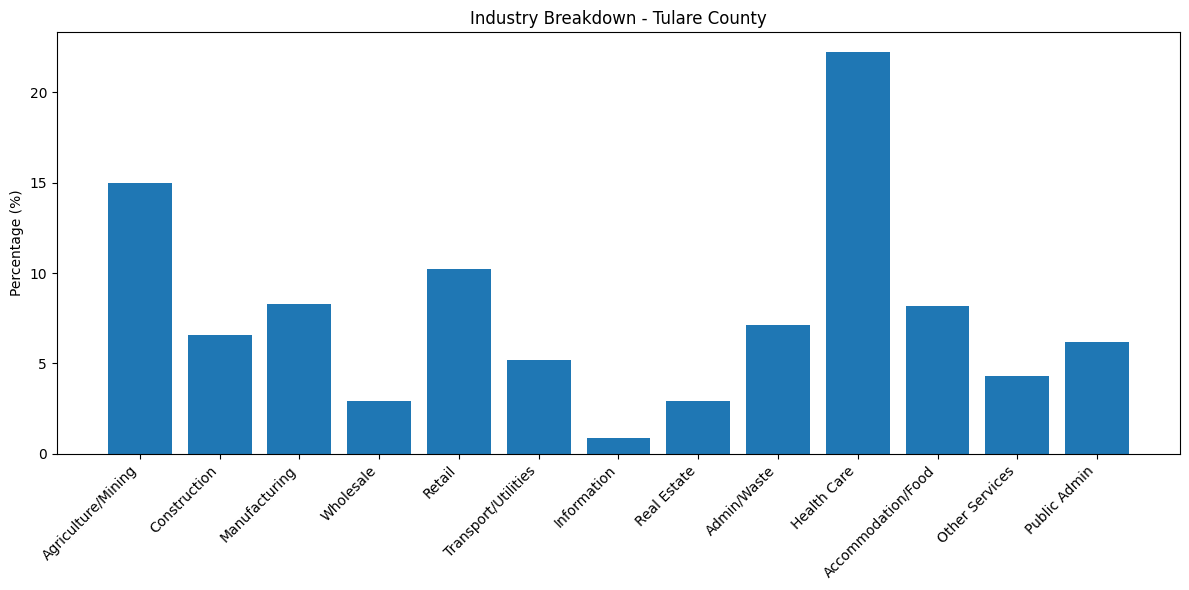

In [6]:
tulare = ACS_final[ACS_final['county'] == 'Tulare County'].iloc[0]

industry_labels = ['Agriculture/Mining', 'Construction', 'Manufacturing', 'Wholesale', 'Retail',
                   'Transport/Utilities', 'Information', 'Real Estate', 'Admin/Waste',
                   'Health Care', 'Accommodation/Food', 'Other Services', 'Public Admin']
industry_cols = ['pct_agriculture_mining', 'pct_construction', 'pct_manufacturing',
                 'pct_wholesale_trade', 'pct_retail_trade', 'pct_transportation_warehousing_utilities',
                 'pct_information', 'pct_real_estate_rental_leasing', 'pct_admin_waste_services',
                 'pct_health_care_social_assistance', 'pct_accommodation_food_services',
                 'pct_other_services', 'pct_public_administration']
industry_values = tulare[industry_cols].values

plt.figure(figsize=(12, 6))
plt.bar(industry_labels, industry_values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.title('Industry Breakdown - Tulare County')
plt.tight_layout()
plt.show()

* Subsetting Tulare County and pulling out median age and household income

In [7]:
tulare = ACS_final[ACS_final['county'] == 'Tulare County'].iloc[0]
tulare[['county', 'median_age', 'median_household_income']]

county                     Tulare County
median_age                          31.9
median_household_income          64474.0
Name: 53, dtype: object

* Subetting Modoc County, selecting race percentage columns, and building bar chart for race

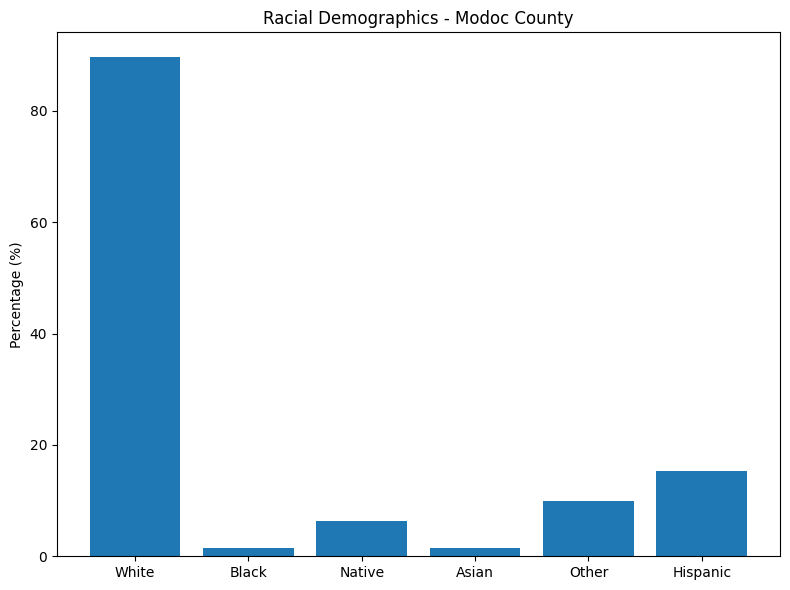

In [8]:
modoc = ACS_final[ACS_final['county'] == 'Modoc County'].iloc[0]

race_labels = ['White', 'Black', 'Native', 'Asian', 'Other', 'Hispanic']
race_cols   = ['pct_white', 'pct_black', 'pct_native', 'pct_asian', 'pct_other', 'pct_hispanic']
race_values = modoc[race_cols].values

plt.figure(figsize=(8, 6))
plt.bar(race_labels, race_values)
plt.ylabel('Percentage (%)')
plt.title('Racial Demographics - Modoc County')
plt.tight_layout()
plt.show()

* Subetting Modoc County, selecting industry percentage columns, and building bar chart for industry of employment

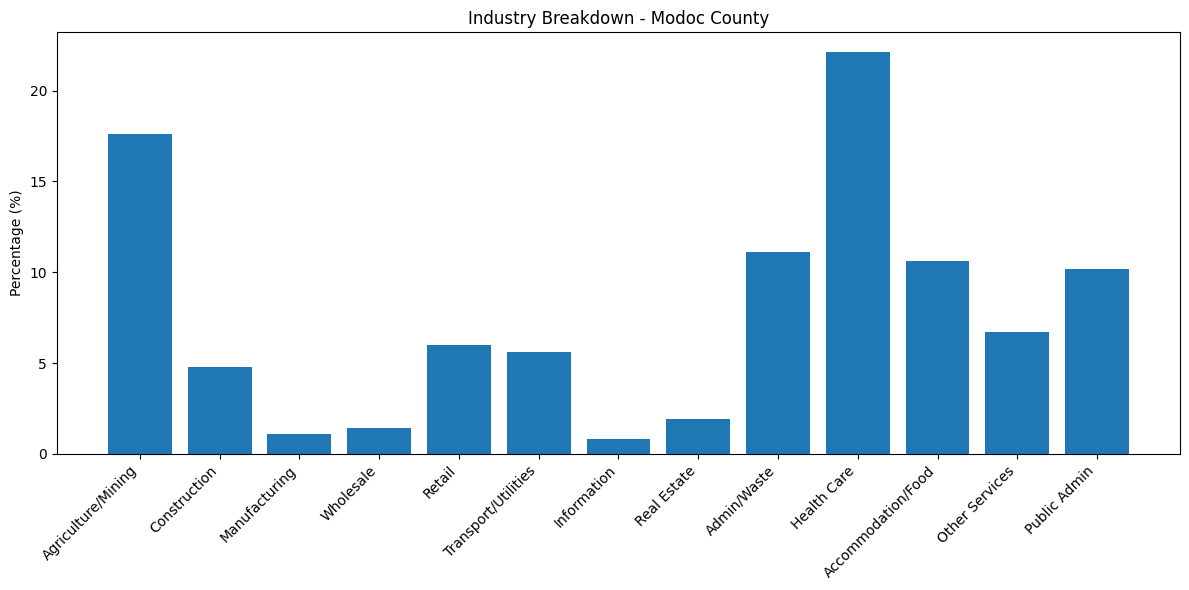

In [9]:
modoc = ACS_final[ACS_final['county'] == 'Modoc County'].iloc[0]

industry_labels = ['Agriculture/Mining', 'Construction', 'Manufacturing', 'Wholesale', 'Retail',
                   'Transport/Utilities', 'Information', 'Real Estate', 'Admin/Waste',
                   'Health Care', 'Accommodation/Food', 'Other Services', 'Public Admin']
industry_cols = ['pct_agriculture_mining', 'pct_construction', 'pct_manufacturing',
                 'pct_wholesale_trade', 'pct_retail_trade', 'pct_transportation_warehousing_utilities',
                 'pct_information', 'pct_real_estate_rental_leasing', 'pct_admin_waste_services',
                 'pct_health_care_social_assistance', 'pct_accommodation_food_services',
                 'pct_other_services', 'pct_public_administration']
industry_values = modoc[industry_cols].values

plt.figure(figsize=(12, 6))
plt.bar(industry_labels, industry_values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.title('Industry Breakdown - Modoc County')
plt.tight_layout()
plt.show()

* Subsetting Modoc County and pulling out median age and household income

In [10]:
modoc = ACS_final[ACS_final['county'] == 'Modoc County'].iloc[0]
modoc[['county', 'median_age', 'median_household_income']]

county                     Modoc County
median_age                         49.0
median_household_income         54962.0
Name: 24, dtype: object